# Empirical application - Gaussian and non-Gaussian GARCH models

This notebook is designed for the HEC Lausanne EMiF course.

Objective:
1. Load a daily S&P 500 price series.
2. Compute daily log returns.
3. Estimate a Gaussian GARCH(1,1).
4. Estimate a Student-t GARCH(1,1).
5. Compare one-step-ahead volatility forecasts with Patton-style loss functions.

The code intentionally avoids black-box GARCH packages. The objective is to make the recursion and the likelihood visible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import norm

## 1. Load the data

The Excel file should be placed next to this notebook. The file used for the slides is `sp500.xlsx`.

In [2]:
DATA_FILE = Path("sp500.xlsx")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Could not find sp500.xlsx. Place the Excel file in the same folder as this notebook."
    )

raw = pd.read_excel(DATA_FILE, sheet_name=0)
raw = raw.rename(columns={raw.columns[0]: "Date", raw.columns[1]: "SP500"})
raw["Date"] = pd.to_datetime(raw["Date"])
raw = raw.dropna().sort_values("Date").set_index("Date")

price = raw["SP500"].astype(float)
returns = 100 * np.log(price).diff().dropna()
returns.name = "S&P 500 log return (%)"

returns.head()

Date
1990-01-02    1.764199
1990-01-03   -0.258891
1990-01-04   -0.865031
1990-01-05   -0.980414
1990-01-08    0.450432
Name: S&P 500 log return (%), dtype: float64

## 2. Visualize returns and volatility clustering

Large absolute returns tend to be followed by large absolute returns. This is the empirical pattern GARCH models are designed to capture.

/usr/lib/python3.13/copy.py:254: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  y = func(*args)


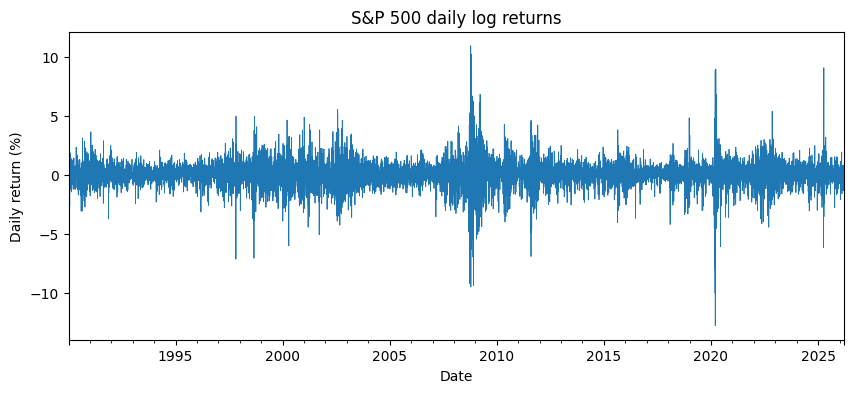

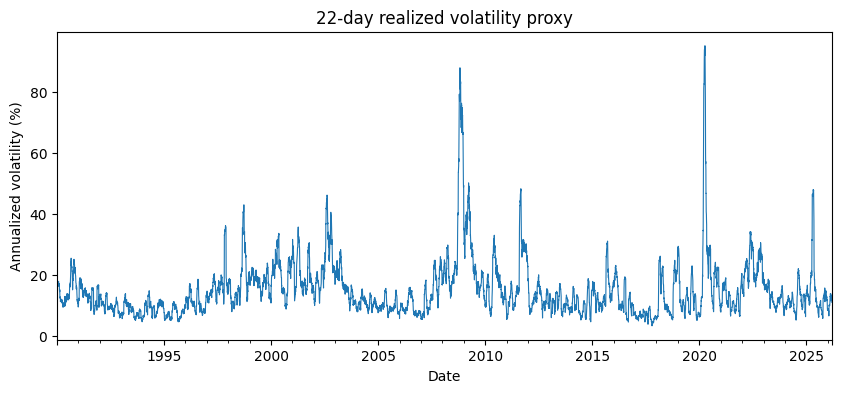

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
returns.plot(ax=ax, linewidth=0.6)
ax.set_title("S&P 500 daily log returns")
ax.set_ylabel("Daily return (%)")
plt.show()

realized_vol_22d = returns.rolling(22).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 4))
realized_vol_22d.plot(ax=ax, linewidth=0.8)
ax.set_title("22-day realized volatility proxy")
ax.set_ylabel("Annualized volatility (%)")
plt.show()

## 3. Split the sample

We estimate the models until the end of 2018, then evaluate one-step-ahead variance forecasts from 2019 onward.

In [4]:
train = returns.loc[returns.index < "2019-01-01"]
test = returns.loc[returns.index >= "2019-01-01"]

print("Training sample:", train.index.min().date(), "to", train.index.max().date(), "|", len(train), "observations")
print("Evaluation sample:", test.index.min().date(), "to", test.index.max().date(), "|", len(test), "observations")

Training sample: 1990-01-02 to 2018-12-31 | 7565 observations
Evaluation sample: 2019-01-01 to 2026-03-11 | 1877 observations


## 4. GARCH(1,1) recursion

The model is:

\begin{align}
r_t &= \mu + \varepsilon_t, \\
\varepsilon_t &= \sigma_t z_t, \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2.
\end{align}

We estimate parameters with a transformation that enforces:

\begin{align}
\omega>0,\qquad \alpha\ge 0,\qquad \beta\ge 0,\qquad \alpha+\beta<1.
\end{align}

In [5]:
def unpack_garch_params(x):
    """Transform unconstrained optimizer variables into valid GARCH parameters."""
    omega = np.exp(x[0])
    a = np.exp(x[1])
    b = np.exp(x[2])
    scale = 1.0 + a + b

    # This guarantees alpha + beta < 0.999.
    alpha = 0.999 * a / scale
    beta = 0.999 * b / scale
    mu = x[3]
    return mu, omega, alpha, beta


def pack_starting_values(mu, omega, alpha, beta):
    """Approximate inverse transform used only to create starting values."""
    gap = max(0.999 - alpha - beta, 1e-4)
    a = alpha / gap
    b = beta / gap
    return np.array([np.log(omega), np.log(a), np.log(b), mu])


def garch_filter(residuals, omega, alpha, beta, init_var=None):
    """Compute the conditional variance path for fixed parameters."""
    residuals = np.asarray(residuals)
    T = len(residuals)
    sigma2 = np.empty(T)

    if init_var is None:
        init_var = np.var(residuals)

    sigma2[0] = init_var

    for t in range(1, T):
        sigma2[t] = omega + alpha * residuals[t - 1] ** 2 + beta * sigma2[t - 1]

        # Numerical safety guard.
        if sigma2[t] <= 1e-12 or not np.isfinite(sigma2[t]):
            sigma2[t] = 1e-12

    return sigma2

## 5. Gaussian GARCH likelihood

For Gaussian innovations:

\begin{align}
z_t\sim N(0,1).
\end{align}

The conditional log-likelihood contribution is:

\begin{align}
\log \ell_t(\theta)
= -\frac{1}{2}\left[
\log(2\pi)+\log(\sigma_t^2)+\frac{\varepsilon_t^2}{\sigma_t^2}
\right].
\end{align}

In [6]:
def negative_loglik_gaussian(x, data):
    mu, omega, alpha, beta = unpack_garch_params(x)
    residuals = np.asarray(data) - mu
    sigma2 = garch_filter(residuals, omega, alpha, beta)

    loglik = -0.5 * (
        np.log(2 * np.pi)
        + np.log(sigma2)
        + residuals**2 / sigma2
    )
    return -np.sum(loglik)


data_train = train.values.astype(float)

mu0 = data_train.mean()
var0 = data_train.var()
alpha0 = 0.05
beta0 = 0.93
omega0 = var0 * (1 - alpha0 - beta0)

x0 = pack_starting_values(mu0, omega0, alpha0, beta0)

res_gaussian = minimize(
    negative_loglik_gaussian,
    x0,
    args=(data_train,),
    method="BFGS",
    options={"maxiter": 2000}
)

mu_g, omega_g, alpha_g, beta_g = unpack_garch_params(res_gaussian.x)

print("Optimization success:", res_gaussian.success)
print("mu     =", round(mu_g, 4))
print("omega  =", round(omega_g, 6))
print("alpha  =", round(alpha_g, 4))
print("beta   =", round(beta_g, 4))
print("alpha + beta =", round(alpha_g + beta_g, 4))
print("log-likelihood =", round(-res_gaussian.fun, 2))

Optimization success: False
mu     = 0.0535
omega  = 0.012592
alpha  = 0.0833
beta   = 0.9057
alpha + beta = 0.9889
log-likelihood = -9807.69


## 6. Student-t GARCH likelihood

For Student-t innovations, we use a standardized Student distribution with variance one:

\begin{align}
g(z\mid\nu)
= \frac{\Gamma((\nu+1)/2)}
{\Gamma(\nu/2)\sqrt{\pi(\nu-2)}}
\left(1+\frac{z^2}{\nu-2}\right)^{-(\nu+1)/2}.
\end{align}

The degrees-of-freedom parameter \(\nu\) controls tail thickness. Lower \(\nu\) means fatter tails.

In [7]:
def unpack_student_params(x):
    mu, omega, alpha, beta = unpack_garch_params(x[:4])
    nu = 2.05 + np.exp(x[4])  # guarantees nu > 2
    return mu, omega, alpha, beta, nu


def negative_loglik_student(x, data):
    mu, omega, alpha, beta, nu = unpack_student_params(x)
    residuals = np.asarray(data) - mu
    sigma2 = garch_filter(residuals, omega, alpha, beta)
    z = residuals / np.sqrt(sigma2)

    log_density_z = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(np.pi * (nu - 2))
        - ((nu + 1) / 2) * np.log(1 + z**2 / (nu - 2))
    )

    loglik = log_density_z - 0.5 * np.log(sigma2)
    return -np.sum(loglik)


x0_student = np.r_[res_gaussian.x, np.log(8 - 2.05)]

res_student = minimize(
    negative_loglik_student,
    x0_student,
    args=(data_train,),
    method="BFGS",
    options={"maxiter": 3000}
)

mu_t, omega_t, alpha_t, beta_t, nu_t = unpack_student_params(res_student.x)

print("Optimization success:", res_student.success)
print("mu     =", round(mu_t, 4))
print("omega  =", round(omega_t, 6))
print("alpha  =", round(alpha_t, 4))
print("beta   =", round(beta_t, 4))
print("alpha + beta =", round(alpha_t + beta_t, 4))
print("nu     =", round(nu_t, 2))
print("log-likelihood =", round(-res_student.fun, 2))

Optimization success: False
mu     = 0.0625
omega  = 0.006469
alpha  = 0.079
beta   = 0.92
alpha + beta = 0.999
nu     = 5.38
log-likelihood = -9582.92


## 7. Compare in-sample density fit

AIC and BIC penalize models with more parameters:

\begin{align}
AIC &= 2k - 2\log L, \\
BIC &= k\log(T) - 2\log L.
\end{align}

In [8]:
def information_criteria(loglik, k, n):
    aic = 2 * k - 2 * loglik
    bic = k * np.log(n) - 2 * loglik
    return aic, bic

summary = pd.DataFrame(
    {
        "loglik": [-res_gaussian.fun, -res_student.fun],
        "k": [4, 5],
    },
    index=["Gaussian GARCH", "Student-t GARCH"],
)

summary["AIC"], summary["BIC"] = zip(*[
    information_criteria(row["loglik"], int(row["k"]), len(train))
    for _, row in summary.iterrows()
])

summary

,loglik,k,AIC,BIC
Gaussian GARCH,-9807.691012,4,19623.382024,19651.107174
Student-t GARCH,-9582.918230,5,19175.836460,19210.492898


## 8. Filter volatility and inspect standardized residuals

The standardized residuals should look closer to iid noise than the raw returns:

\begin{align}
\hat z_t = \frac{r_t-\hat\mu}{\hat\sigma_t}.
\end{align}

/usr/lib/python3.13/copy.py:254: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  y = func(*args)


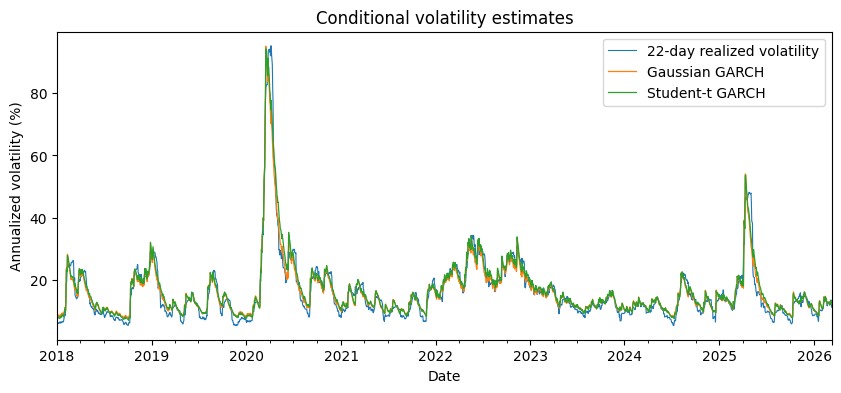

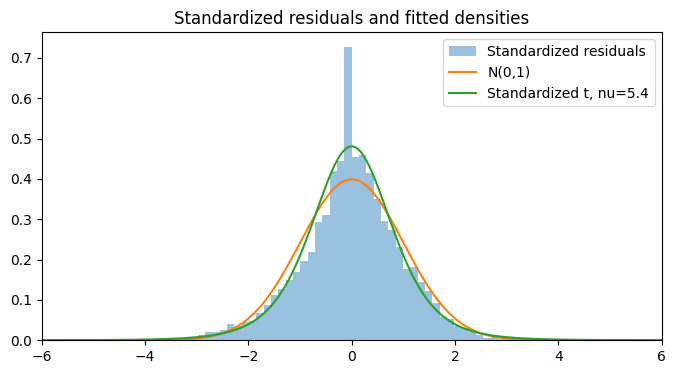

In [9]:
all_data = returns.values.astype(float)

sigma2_g_all = garch_filter(all_data - mu_g, omega_g, alpha_g, beta_g)
sigma2_t_all = garch_filter(all_data - mu_t, omega_t, alpha_t, beta_t)

vol_g = pd.Series(np.sqrt(252 * sigma2_g_all), index=returns.index, name="Gaussian GARCH")
vol_t = pd.Series(np.sqrt(252 * sigma2_t_all), index=returns.index, name="Student-t GARCH")

fig, ax = plt.subplots(figsize=(10, 4))
realized_vol_22d.loc["2018":].plot(ax=ax, linewidth=0.8, label="22-day realized volatility")
vol_g.loc["2018":].plot(ax=ax, linewidth=0.9)
vol_t.loc["2018":].plot(ax=ax, linewidth=0.9)
ax.set_title("Conditional volatility estimates")
ax.set_ylabel("Annualized volatility (%)")
ax.legend()
plt.show()

z_g = pd.Series((all_data - mu_g) / np.sqrt(sigma2_g_all), index=returns.index)

x = np.linspace(-6, 6, 400)

def standardized_t_pdf(x, nu):
    return np.exp(
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(np.pi * (nu - 2))
        - ((nu + 1) / 2) * np.log(1 + x**2 / (nu - 2))
    )

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(z_g.dropna(), bins=80, density=True, alpha=0.45, label="Standardized residuals")
ax.plot(x, norm.pdf(x), label="N(0,1)")
ax.plot(x, standardized_t_pdf(x, nu_t), label=f"Standardized t, nu={nu_t:.1f}")
ax.set_xlim(-6, 6)
ax.set_title("Standardized residuals and fitted densities")
ax.legend()
plt.show()

## 9. One-step-ahead volatility forecasts

For evaluation, we use one-step-ahead variance forecasts and compare them to the squared return proxy:

\begin{align}
\tilde{\sigma}_{t+1}^2 = r_{t+1}^2.
\end{align}

This proxy is noisy, but it is simple and sufficient for the classroom application.

In [10]:
variance_forecast_g = pd.Series(sigma2_g_all, index=returns.index, name="Gaussian variance forecast")
variance_forecast_t = pd.Series(sigma2_t_all, index=returns.index, name="Student-t variance forecast")

proxy = returns**2
evaluation_index = returns.index >= "2019-01-01"

eval_df = pd.DataFrame(
    {
        "proxy_squared_return": proxy.loc[evaluation_index],
        "variance_forecast_gaussian": variance_forecast_g.loc[evaluation_index],
        "variance_forecast_student": variance_forecast_t.loc[evaluation_index],
    }
)

eval_df.head()

,proxy_squared_return,variance_forecast_gaussian,variance_forecast_student
Date,,,
2019-01-01,0.000000,3.132654,3.289176
2019-01-02,0.016071,2.849933,3.032961
2019-01-03,6.284185,2.594094,2.797249
2019-01-04,11.396956,2.907793,3.101274
2019-01-07,0.488039,3.565240,3.726620


## 10. Patton-style forecast losses

Two robust loss functions for variance forecasts are:

\begin{align}
L_{MSE}(\tilde\sigma^2,\hat\sigma^2)
&= (\tilde\sigma^2-\hat\sigma^2)^2, \\
L_{QLIKE}(\tilde\sigma^2,\hat\sigma^2)
&= \log(\hat\sigma^2)+\frac{\tilde\sigma^2}{\hat\sigma^2}.
\end{align}

QLIKE is often useful in risk management because it strongly penalizes forecasts that are too low.

In [11]:
def mse_loss(proxy, forecast):
    return (proxy - forecast) ** 2

def qlike_loss(proxy, forecast):
    return np.log(forecast) + proxy / forecast

losses = pd.DataFrame(index=eval_df.index)
losses["Gaussian_MSE"] = mse_loss(eval_df["proxy_squared_return"], eval_df["variance_forecast_gaussian"])
losses["Student_MSE"] = mse_loss(eval_df["proxy_squared_return"], eval_df["variance_forecast_student"])
losses["Gaussian_QLIKE"] = qlike_loss(eval_df["proxy_squared_return"], eval_df["variance_forecast_gaussian"])
losses["Student_QLIKE"] = qlike_loss(eval_df["proxy_squared_return"], eval_df["variance_forecast_student"])

losses.mean().to_frame("Average loss")

,Average loss
Gaussian_MSE,32.131450
Student_MSE,32.961585
Gaussian_QLIKE,0.916107
Student_QLIKE,0.928405


## 11. A simple Diebold-Mariano comparison

Let the loss differential be:

\begin{align}
d_t = L_{1,t} - L_{2,t}.
\end{align}

If \(\bar d > 0\), model 2 has lower average loss. If \(\bar d < 0\), model 1 has lower average loss.

In [12]:
def simple_dm_stat(loss_model_1, loss_model_2):
    d = (loss_model_1 - loss_model_2).dropna()
    return d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))

dm_mse = simple_dm_stat(losses["Gaussian_MSE"], losses["Student_MSE"])
dm_qlike = simple_dm_stat(losses["Gaussian_QLIKE"], losses["Student_QLIKE"])

print("DM statistic, MSE loss    :", round(dm_mse, 2))
print("DM statistic, QLIKE loss  :", round(dm_qlike, 2))
print("Interpretation: negative values mean Gaussian GARCH has lower average loss here.")

DM statistic, MSE loss    : -4.03
DM statistic, QLIKE loss  : -3.35
Interpretation: negative values mean Gaussian GARCH has lower average loss here.


## 12. Main interpretation

The Student-t model usually improves the conditional density fit because it allows fat-tailed innovations.

But the volatility forecast comparison can be more ambiguous:
- better density fit does not mechanically imply better variance forecasts;
- the squared-return proxy is noisy;
- the evaluation period contains unusual crisis episodes;
- model rankings can depend on the loss function.

This is exactly why volatility forecast evaluation is a separate empirical step.